In [1]:
import geopandas as gpd

In [2]:
gdf = gpd.read_file("../data/complimentary/ao.shp")

In [3]:
gdf.head()

,NAME,OKATO,ABBREV,geometry
0,Троицкий,45298000,Троицкий,"MULTIPOLYGON (((36.8031 55.44083, 36.80319 55...."
1,Новомосковский,45297000,Новомосковский,"MULTIPOLYGON (((37.08697 55.59036, 37.09492 55..."
2,Зеленоградский,45272000,ЗелАО,"POLYGON ((37.1316 56.01645, 37.13266 56.01678,..."
3,Юго-Западный,45293000,ЮЗАО,"POLYGON ((37.45572 55.63705, 37.46372 55.6407,..."
4,Юго-Восточный,45290000,ЮВАО,"MULTIPOLYGON (((37.66069 55.7307, 37.66082 55...."


In [6]:
names = gdf["NAME"]
print(names.unique())

<ArrowStringArray>
[        'Троицкий',   'Новомосковский',   'Зеленоградский',
     'Юго-Западный',    'Юго-Восточный',      'Центральный',
         'Северный',  'Северо-Западный', 'Северо-Восточный',
            'Южный',        'Восточный',         'Западный']
Length: 12, dtype: str


In [7]:
names = gdf["ABBREV"]
print(names.unique())

<ArrowStringArray>
[      'Троицкий', 'Новомосковский',          'ЗелАО',           'ЮЗАО',
           'ЮВАО',            'ЦАО',            'САО',           'СЗАО',
           'СВАО',            'ЮАО',            'ВАО',            'ЗАО']
Length: 12, dtype: str


In [10]:
import pandas as pd

In [ ]:
df = pd.read_parquet("../data/interim/04_mean_knn.parquet")

In [ ]:
import pandas as pd
import geopandas as gpd


def add_administrative_district(df, shp_path):
    # 1. Create a GeoDataFrame from the input DataFrame
    points_gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
        crs="EPSG:4326",
    )

    districts_gdf = gpd.read_file(shp_path)

    districts_gdf = districts_gdf.to_crs(points_gdf.crs)

    joined_gdf = gpd.sjoin(
        points_gdf, districts_gdf[["NAME", "geometry"]], how="left", predicate="within"
    )

    joined_gdf = joined_gdf.drop(columns=["index_right", "geometry"])
    joined_gdf = joined_gdf.rename(columns={"NAME": "administrative_district"})

    return joined_gdf

In [13]:
df = add_administrative_district(df, "../data/complimentary/ao.shp")

In [14]:
df.head()

,address,longitude,latitude,area,room_count,floor,floor_count,market_type,flat_type,ceiling_height,...,date,period,discount_index,price_per_square_meter_normalized,price_normalized,max_distance_knn,knn_weighted_price_normalized,knn_weighted_price_per_square_meter_normalized,primary_to_secondary_price_ratio,administrative_district
0,"1-й Дубровский пр-д, вл. 78/14, к. 1.4",37.683254,55.724456,58.31,2,16,<NA>,primary,flat,NaN,...,2015-01-05,2015-01-01,NaN,NaN,NaN,0.0,NaN,NaN,NaN,Юго-Восточный
1,"Складочная ул., вл. 1, к. С1",37.591410,55.803160,67.20,1,13,<NA>,primary,flat,NaN,...,2015-04-18,2015-04-01,NaN,NaN,NaN,0.0,NaN,NaN,NaN,Северо-Восточный
2,"Волоколамское шоссе, вл. 67, кв-л 1",37.429197,55.811208,37.90,1,9,<NA>,primary,flat,NaN,...,2015-05-03,2015-05-01,NaN,NaN,NaN,0.0,NaN,NaN,NaN,Северо-Западный
3,"Волоколамское шоссе, вл. 67, кв-л 1",37.429197,55.811208,87.90,3,12,<NA>,primary,flat,NaN,...,2015-05-11,2015-05-01,NaN,NaN,NaN,0.0,NaN,NaN,NaN,Северо-Западный
4,"Складочная ул., вл. 1, к. С1",37.591410,55.803160,67.20,1,21,<NA>,primary,flat,NaN,...,2015-06-07,2015-06-01,0.233448,935986.966019,6.289832e+07,0.0,NaN,NaN,NaN,Северо-Восточный


In [ ]:
df["administrative_district"].unique()

<ArrowStringArray>
[   'Юго-Восточный', 'Северо-Восточный',  'Северо-Западный',
      'Центральный',            'Южный',     'Юго-Западный',
        'Восточный',         'Северный',         'Западный',
   'Новомосковский',   'Зеленоградский',                nan,
         'Троицкий']
Length: 13, dtype: str

In [ ]:
df["administrative_district"].describe()

count             864827
unique                12
top       Новомосковский
freq              226037
Name: administrative_district, dtype: object

In [20]:
missing = df["administrative_district"].isna().sum()
total = len(df)

print(missing, total, missing / total)

471576 1336403 0.3528696059497023


In [21]:
shp_path = "../data/complimentary/ao.shp"

In [22]:
points_gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326",
)

# 2. Read the districts shapefile
districts_gdf = gpd.read_file(shp_path)

# 3. Ensure both GeoDataFrames have the same CRS
districts_gdf = districts_gdf.to_crs(points_gdf.crs)

# 4. Perform the spatial join
# We want to find which district each point is 'within'
# A 'left' join ensures we keep all original points
joined_gdf = gpd.sjoin(
    points_gdf, districts_gdf[["NAME", "geometry"]], how="left", predicate="within"
)

# 5. Clean up the result
# The join might add an 'index_right' column, which we can drop.
# We rename the district name column to be more generic.
joined_gdf = joined_gdf.drop(columns=["index_right", "geometry"])
joined_gdf = joined_gdf.rename(columns={"NAME": "administrative_district"})


/home/gelerum/1Projects/primary-vs-secondary/env/lib64/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


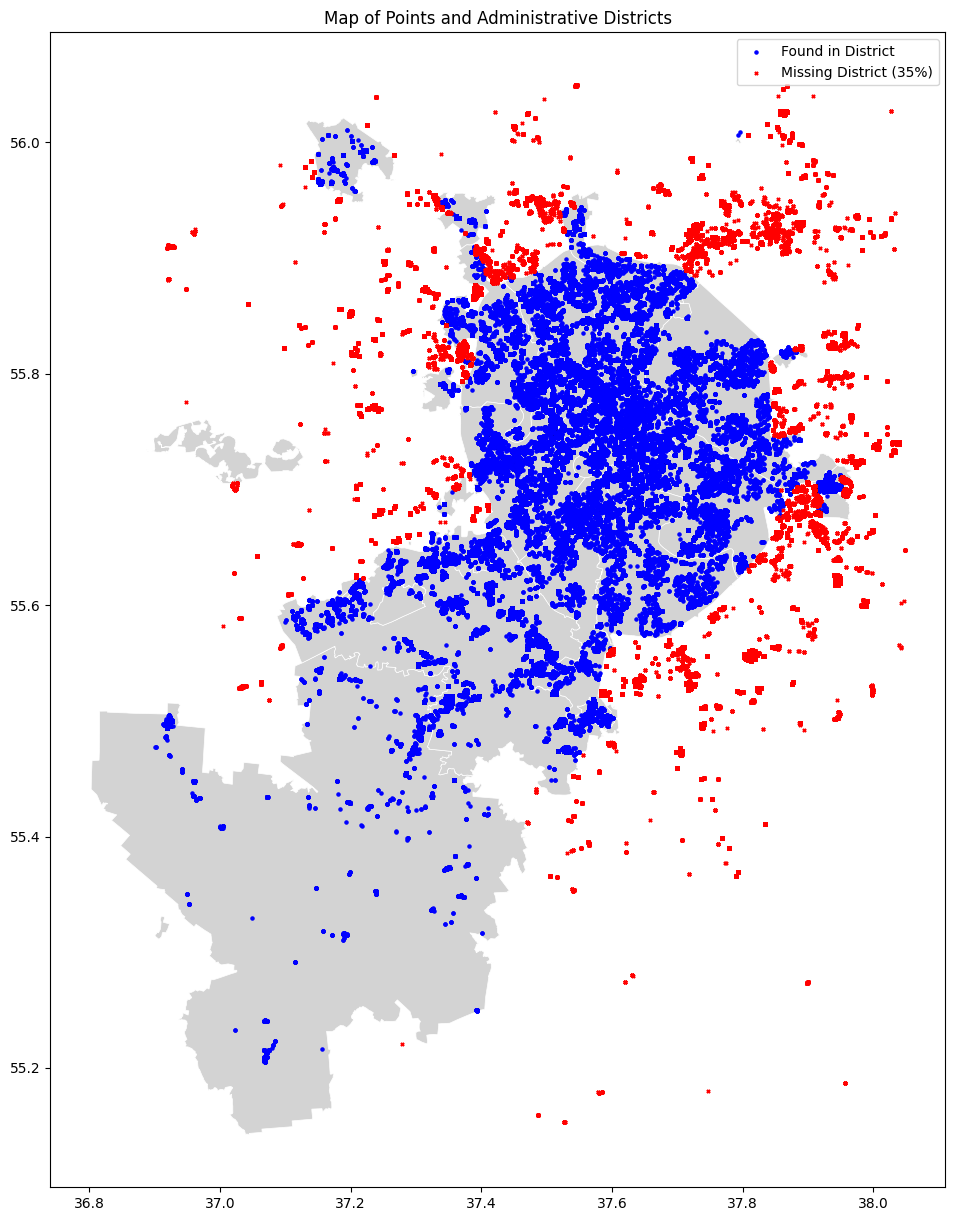

In [24]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Assume 'joined_df' is the GeoDataFrame right after the sjoin
# and 'districts_gdf' is the GeoDataFrame of your polygons.

# If you don't have these, you can recreate them:
points_gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df["longitude"], df["latitude"]), crs="EPSG:4326"
)
districts_gdf = gpd.read_file(shp_path).to_crs(points_gdf.crs)

# Separate the points that found a match from those that did not
missing_points = points_gdf[df["administrative_district"].isna()]
found_points = points_gdf[df["administrative_district"].notna()]

# --- Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# 1. Plot the base layer of district polygons
districts_gdf.plot(ax=ax, facecolor="lightgray", edgecolor="white", linewidth=0.5)

# 2. Plot the points that were successfully matched
# We plot these first so the missing ones will appear on top
found_points.plot(
    ax=ax, marker="o", color="blue", markersize=5, label="Found in District"
)

# 3. Plot the points that are MISSING a district in a different color
missing_points.plot(
    ax=ax, marker="x", color="red", markersize=5, label="Missing District (35%)"
)

# Add title and legend
plt.title("Map of Points and Administrative Districts")
plt.legend()
plt.show()